# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
import pickle

import numpy as np

from impl.mr.predefined import mr_set1, mr_set3
from impl.utils.visualization import visualize_archived_distinct_solutions, visualize_archived_solutions_by_gen, \
    visualize_archive_solution_over_generations, visualize_distinct_solution_over_simulations, \
    visualize_computational_efficiency

# Prepare data

In [2]:
set1_solutions = {
    "ccea": [
        "1727209526466", "1727240994672", "1727266901005", "1727295192682", "1727323277274",
        "1727350900214", "1727380354661", "1727411465615", "1727439594179", "1727469833556",
    ],
    "ga": [
        "1727222567297", "1727250570553", "1727277786075", "1727305247085", "1727332417742",
        "1727360236396", "1727391457944", "1727421077088", "1727450998141", "1727480862318",
    ],
    "rs": [
        "1727232907851", "1727259420090", "1727286578674", "1727314239612", "1727341179646",
        "1727369189391", "1727401251184", "1727430452614", "1727460765043", "1727490053161",
    ],
}
set1_checkpoints = {
    "ccea": [
        ["1727201519649.pickle", "1727209525799.pickle"],
        ["1727235598273.pickle", "1727240994238.pickle"],
        ["1727261716665.pickle", "1727266900474.pickle"],
        ["1727288292889.pickle", "1727295192277.pickle"],
        ["1727316247139.pickle", "1727323276634.pickle"],
        ["1727343419222.pickle", "1727350899632.pickle"],
        ["1727373922607.pickle", "1727380353945.pickle"],
        ["1727403610820.pickle", "1727411465040.pickle"],
        ["1727432664046.pickle", "1727439593383.pickle"],
        ["1727462943800.pickle", "1727469832790.pickle"],
    ],
    "ga": [
        ["1727209911905.pickle", "1727222566366.pickle"],
        ["1727241404211.pickle", "1727250570021.pickle"],
        ["1727267613418.pickle", "1727277785562.pickle"],
        ["1727295908578.pickle", "1727305246414.pickle"],
        ["1727323806097.pickle", "1727332417270.pickle"],
        ["1727351350346.pickle", "1727360235858.pickle"],
        ["1727380896561.pickle", "1727391457305.pickle"],
        ["1727412055217.pickle", "1727421076474.pickle"],
        ["1727440319781.pickle", "1727450997411.pickle"],
        ["1727470376451.pickle", "1727480861750.pickle"],
    ],
    "rs": [
        ["1727223364731.pickle", "1727232907448.pickle"],
        ["1727251274947.pickle", "1727259419608.pickle"],
        ["1727278306501.pickle", "1727286578130.pickle"],
        ["1727306232310.pickle", "1727314239208.pickle"],
        ["1727333077420.pickle", "1727341179299.pickle"],
        ["1727360732518.pickle", "1727369188866.pickle"],
        ["1727392085249.pickle", "1727401250811.pickle"],
        ["1727421643803.pickle", "1727430452209.pickle"],
        ["1727451559666.pickle", "1727460764631.pickle"],
        ["1727481385453.pickle", "1727490052651.pickle"],
    ],
}

In [3]:
set2_solutions = {
    "ccea": [
        "1741032710545", "1741119044541", "1741133260050", "1741371161233", "1741392734894",
        "1741426816957", "1741474427157", "1741507603153", "1741537705368", "1741570473728",
    ],
    "ga": [
        "1741310808939", "1741333925266", "1741383025520", "1741403850515", "1741439105617",
        "1741486019659", "1741514899673", "1741549032347", "1741582504457", "1741640145181",
    ],
    "rs": [
        "1741322261176", "1741345278307", "1741415716193", "1741450997250", "1741463466915",
        "1741497754696", "1741527214047", "1741560891313", "1741594700220", "1741652914235",
    ],
}
set2_checkpoints = {
    "ccea": [
        ["1741022812945.pickle", "1741032710254.pickle"],
        ["1741110608819.pickle", "1741119044114.pickle"],
        ["1741125065905.pickle", "1741133259800.pickle"],
        ["1741362486684.pickle", "1741371160938.pickle"],
        ["1741385437697.pickle", "1741392734507.pickle"],
        ["1741418208255.pickle", "1741426816504.pickle"],
        ["1741465983711.pickle", "1741474426707.pickle"],
        ["1741499537263.pickle", "1741507602739.pickle"],
        ["1741529327364.pickle", "1741537704969.pickle"],
        ["1741562716874.pickle", "1741570473481.pickle"],
    ],
    "ga": [
        ["1741293529799.pickle", "1741310808477.pickle"],
        ["1741322691009.pickle", "1741333924835.pickle"],
        ["1741371803181.pickle", "1741382682506.pickle"],
        ["1741393143812.pickle", "1741403850135.pickle"],
        ["1741427215364.pickle", "1741439105210.pickle"],
        ["1741475045971.pickle", "1741486019397.pickle"],
        ["1741508396733.pickle", "1741514899522.pickle"],
        ["1741538098902.pickle", "1741549031974.pickle"],
        ["1741570892570.pickle", "1741582504182.pickle"],
        ["1741629481228.pickle", "1741640144683.pickle"],
    ],
    "rs": [
        ["1741311220558.pickle", "1741322260952.pickle"],
        ["1741334375132.pickle", "1741345277964.pickle"],
        ["1741404200731.pickle", "1741415715849.pickle"],
        ["1741439899836.pickle", "1741450996902.pickle"],
        ["1741452155827.pickle", "1741463466555.pickle"],
        ["1741486550206.pickle", "1741497754467.pickle"],
        ["1741515243422.pickle", "1741527213688.pickle"],
        ["1741549448068.pickle", "1741560891081.pickle"],
        ["1741582932690.pickle", "1741594699990.pickle"],
        ["1741640616621.pickle", "1741652913874.pickle"],
    ],
}

In [4]:
diversity_solutions = {
    "ccea": [
        "1727209526466", "1727240994672", "1727266901005", "1727295192682", "1727323277274",
        "1727350900214", "1727380354661", "1727411465615", "1727439594179", "1727469833556",
    ],
    "ccea-d": [
        # w/o diversity mechanisms
        "1739580986498", "1739592939566", "1739604209362", "1739614139138", "1739625121408",
        "1739634967424", "1739646147799", "1739656822493", "1739668897019", "1739680709907",
    ],
}
diversity_checkpoints = {
    "ccea": [
        ["1727201519649.pickle", "1727209525799.pickle"],
        ["1727235598273.pickle", "1727240994238.pickle"],
        ["1727261716665.pickle", "1727266900474.pickle"],
        ["1727288292889.pickle", "1727295192277.pickle"],
        ["1727316247139.pickle", "1727323276634.pickle"],
        ["1727343419222.pickle", "1727350899632.pickle"],
        ["1727373922607.pickle", "1727380353945.pickle"],
        ["1727403610820.pickle", "1727411465040.pickle"],
        ["1727432664046.pickle", "1727439593383.pickle"],
        ["1727462943800.pickle", "1727469832790.pickle"],
    ],
    "ccea-d": [
        ["1739571399066.pickle", "1739580986088.pickle"],
        ["1739582864241.pickle", "1739592939170.pickle"],
        ["1739595162262.pickle", "1739604208849.pickle"],
        ["1739606075538.pickle", "1739614138687.pickle"],
        ["1739617339203.pickle", "1739625121042.pickle"],
        ["1739626853470.pickle", "1739634967021.pickle"],
        ["1739636684144.pickle", "1739646147278.pickle"],
        ["1739648579078.pickle", "1739656822118.pickle"],
        ["1739659470270.pickle", "1739668896527.pickle"],
        ["1739671574738.pickle", "1739680709645.pickle"],
    ],
}

# Plots for RQ1

In [5]:
from scipy.spatial.distance import pdist


def quantile(solutions):
    fitnesses = []
    dists = []
    for name, times in solutions.items():
        for time in times:
            path = f"out/solutions/solutions-{name}-{time}.pickle"
            with open(path, "rb") as f:
                solutions = pickle.load(f)
            fitnesses += [sol.fitness.values[0] for sol in solutions]
            if len(solutions) < 2:
                print(f"{path}: {len(solutions)}")
                continue
            follow_ups = []
            for scenario, perturbation in solutions:
                perturbation.perturb(scenario)
                follow_ups.append(scenario)
            dist = pdist(np.array(follow_ups, dtype=object).reshape((len(follow_ups), -1)),
                         lambda x, y: x[0].dist(y[0]))
            dists = np.concatenate((dists, dist))
    return fitnesses, dists

## MR set 1

In [6]:
fitnesses, dists = quantile(set1_solutions)
print(np.quantile(fitnesses, [0.5, 0.7, 0.9]).round(1))
print(np.quantile(dists, [0.1, 0.3, 0.5]).round(1))

[0.3 0.8 1.5]
[1.1 1.5 1.7]


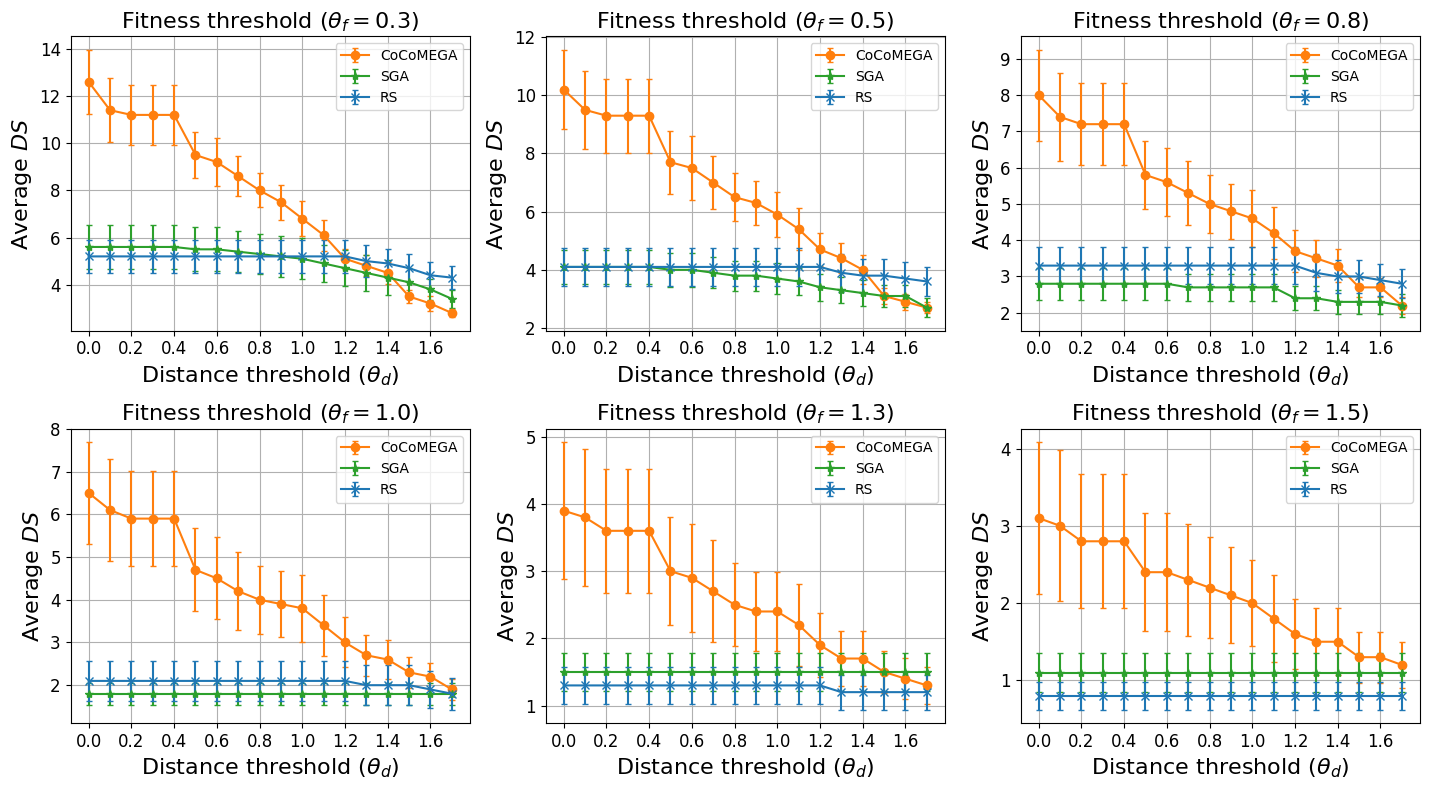

In [7]:
set1_solution_stats = visualize_archived_distinct_solutions(
    {name: [f"out/solutions/solutions-{name}-{time}.pickle" for time in times]
     for name, times in set1_solutions.items()},
    fitness_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
    distance_thresholds=np.arange(0, 1.71, 0.1).round(1),
    mr_set=mr_set1, box=False, show=True)

/home/stk/projects/previous/impl/utils/visualization.py:771: RuntimeWarning: Mean of empty slice
  [np.nanmean(row) + 0.95 * np.nanstd(row) / np.sqrt(np.count_nonzero(~np.isnan(row))) for row in values])
/home/stk/projects/previous/.venv/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1667: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)
/home/stk/projects/previous/impl/utils/visualization.py:773: RuntimeWarning: Mean of empty slice
  [np.nanmean(row) - 0.95 * np.nanstd(row) / np.sqrt(np.count_nonzero(~np.isnan(row))) for row in values])
/home/stk/projects/previous/.venv/lib/python3.7/site-packages/pandas/core/series.py:4045: RuntimeWarning: Mean of empty slice
  mapped = lib.map_infer(values, f, convert=convert_dtype)


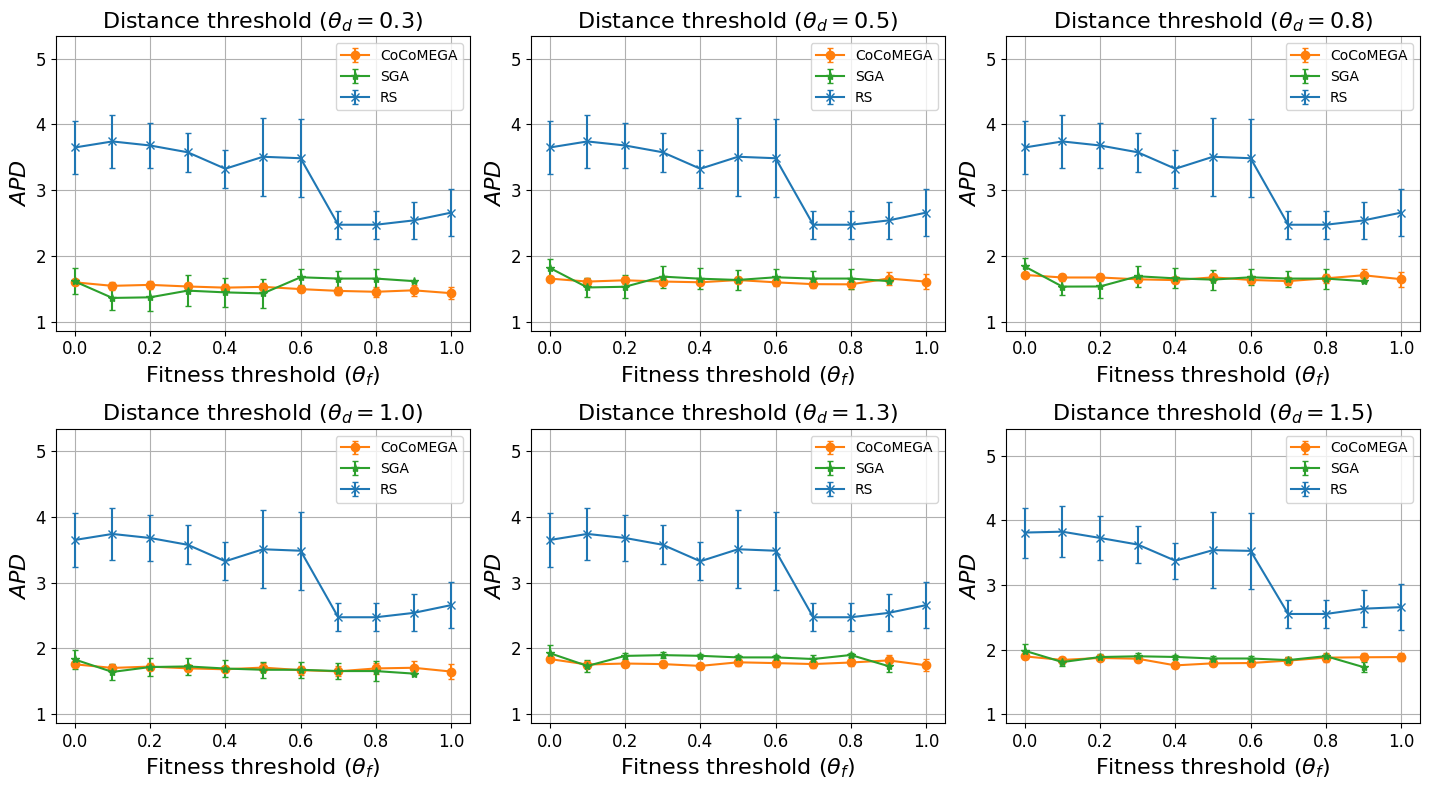

In [8]:
visualize_archived_solutions_by_gen("out/checkpoints", set1_checkpoints, generation_num=7, metric_name="avg_pw",
                                    fitness_thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                    distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
                                    mr_set=mr_set1, box=False, show=True,
                                    legend_loc="upper right", padding={"top": 1.2, "bottom": 0.3})

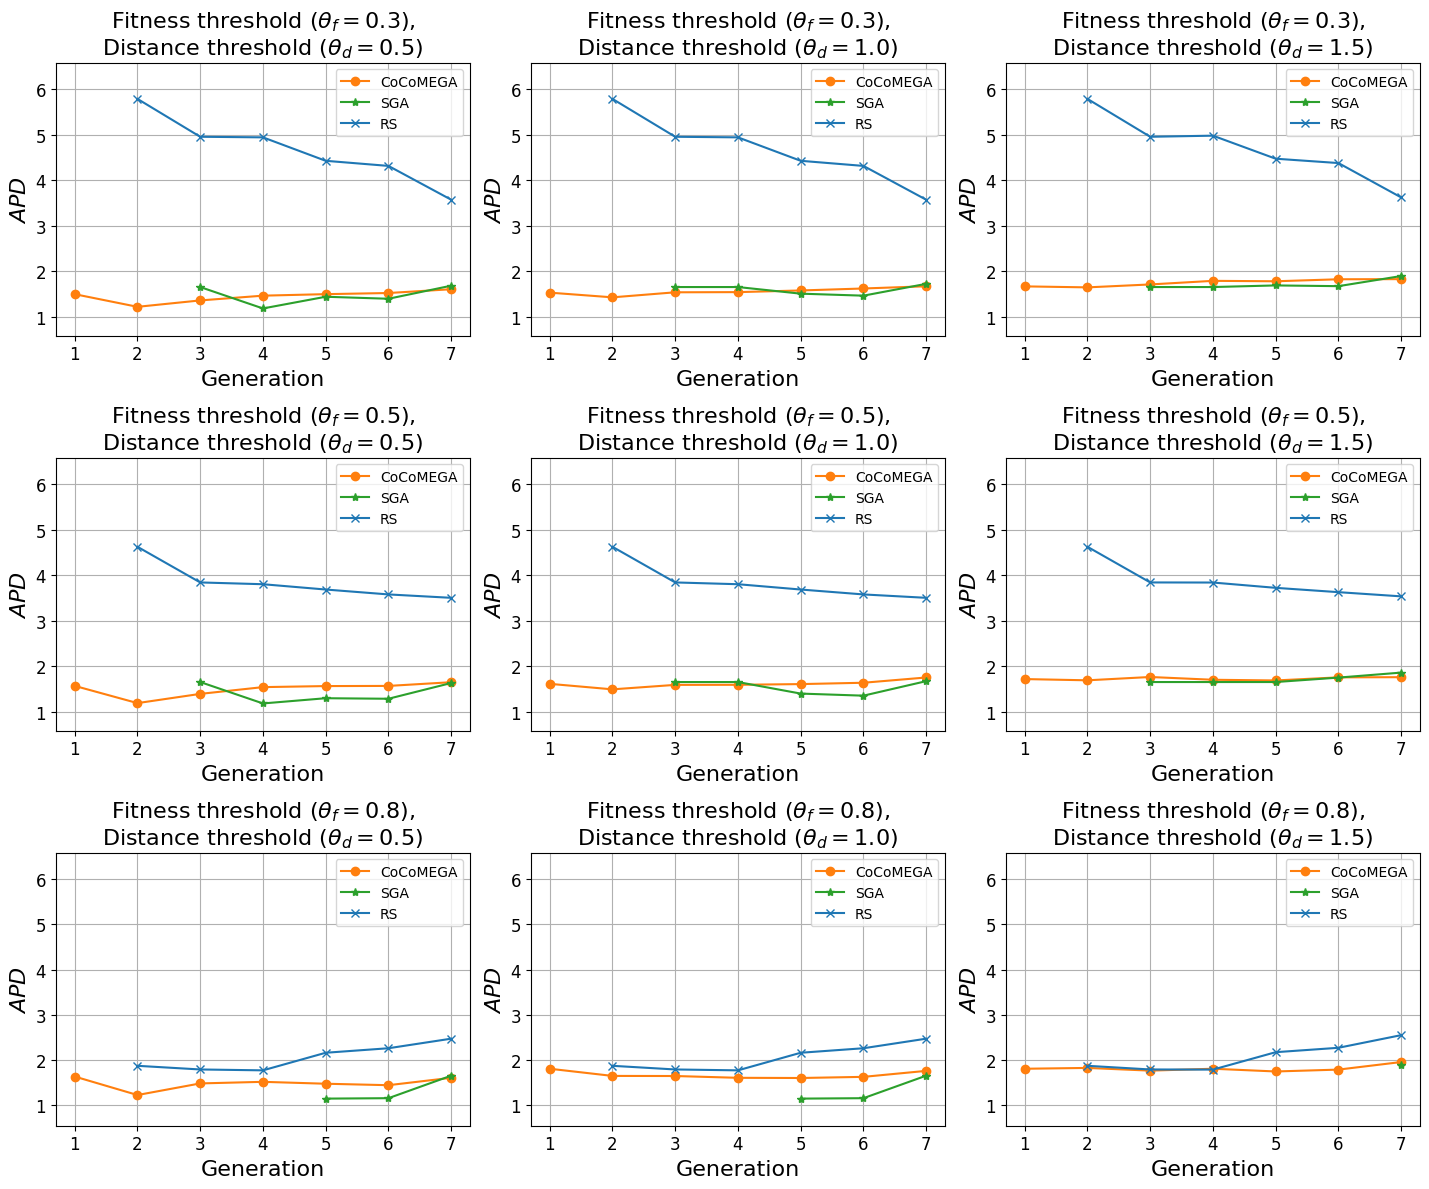

In [9]:
visualize_archive_solution_over_generations("out/checkpoints", set1_checkpoints, metric_name="avg_pw",
                                            fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.5, 1.0, 1.5],
                                            mr_set=mr_set1, max_gen=7, show=True,
                                            legend_loc="upper right", padding={"top": 0.8, "bottom": 0.6})

## MR set 2

In [10]:
from impl.utils.carla_utils import initialize_carla, load_world
from srunner.scenariomanager.carla_data_provider import CarlaDataProvider

initialize_carla()
load_world("Town05")
fitnesses, dists = quantile(set2_solutions)
print(np.quantile(fitnesses, [0.5, 0.7, 0.9]).round(1))
print(np.quantile(dists, [0.1, 0.3, 0.5]).round(1))

out/solutions/solutions-ga-1741310808939.pickle: 0
out/solutions/solutions-ga-1741403850515.pickle: 1
[0.2 0.5 0.9]
[1.2 1.6 1.9]


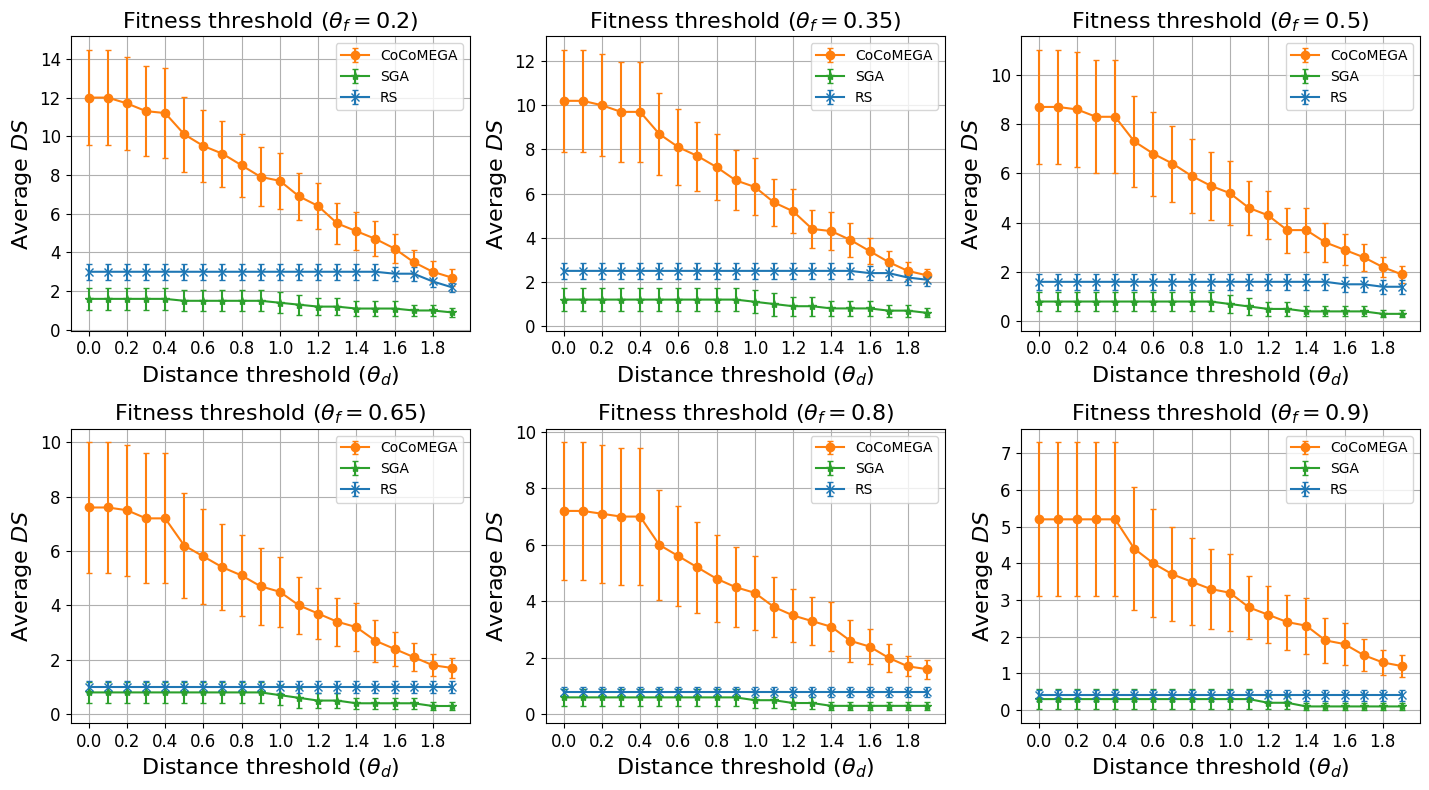

In [11]:
set2_solution_stats = visualize_archived_distinct_solutions(
    {name: [f"out/solutions/solutions-{name}-{time}.pickle" for time in times]
     for name, times in set2_solutions.items()},
    fitness_thresholds=[0.2, 0.35, 0.5, 0.65, 0.8, 0.9],
    distance_thresholds=np.arange(0, 1.91, 0.1).round(1),
    mr_set=mr_set3, box=False, show=True)

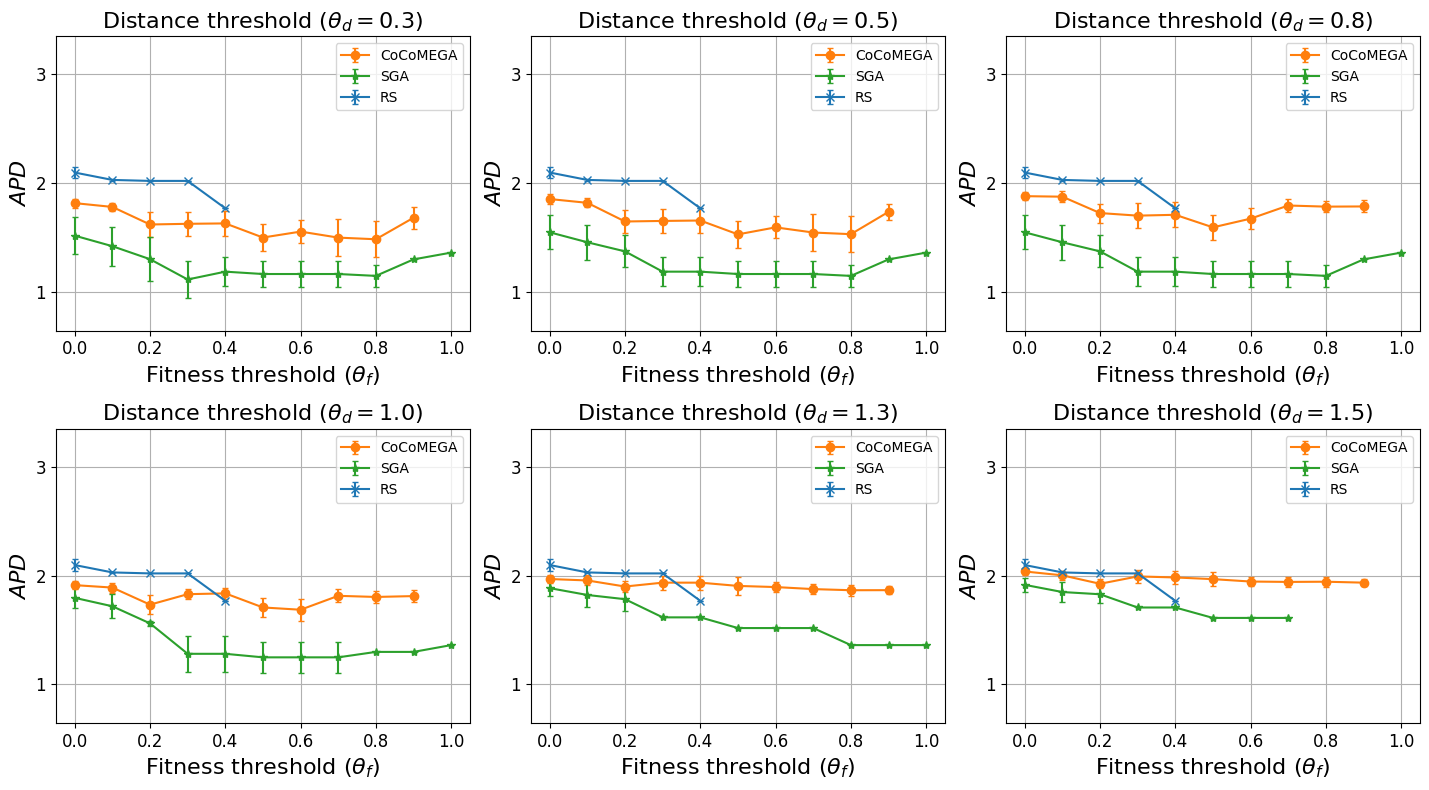

In [12]:
visualize_archived_solutions_by_gen("out/checkpoints", set2_checkpoints, generation_num=7, metric_name="avg_pw",
                                    fitness_thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                    distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
                                    mr_set=mr_set3, box=False, show=True,
                                    legend_loc="upper right", padding={"top": 1.2, "bottom": 0.3})

/home/stk/projects/previous/impl/utils/visualization.py:863: RuntimeWarning: All-NaN axis encountered
  chart_y_max = np.nanmax(group[metric_name].apply(np.nanmean))
/home/stk/projects/previous/impl/utils/visualization.py:864: RuntimeWarning: All-NaN axis encountered
  chart_y_min = np.nanmin(group[metric_name].apply(np.nanmean))


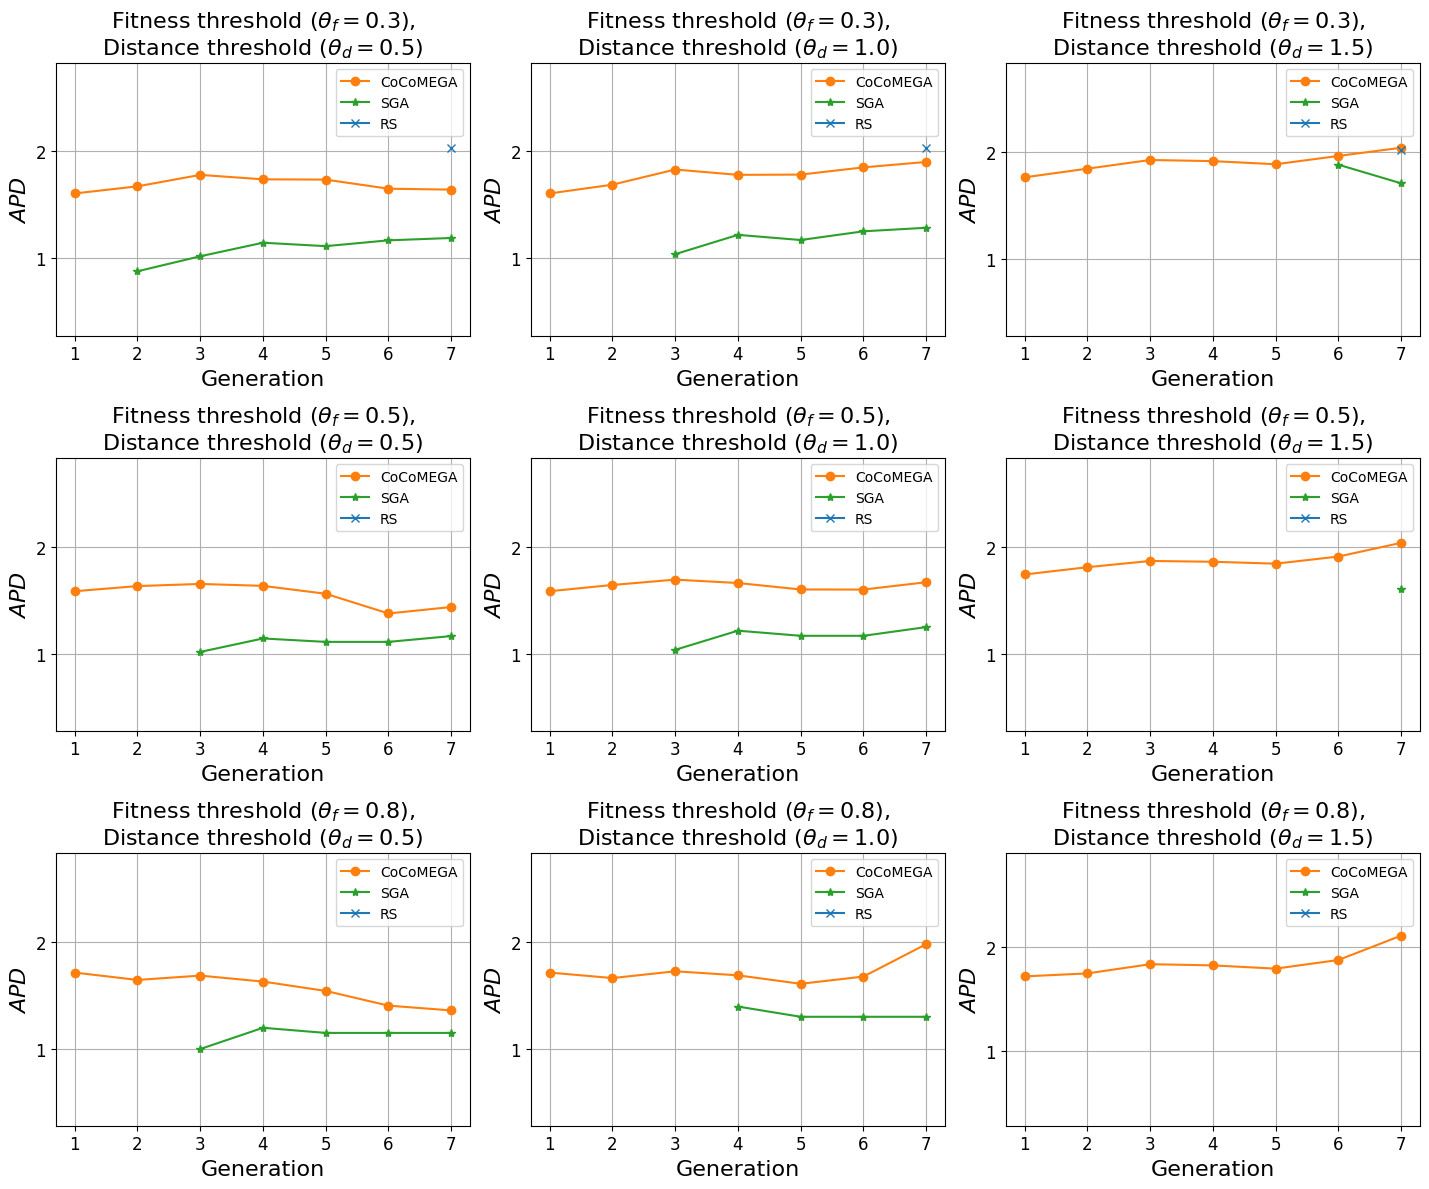

In [13]:
visualize_archive_solution_over_generations("out/checkpoints", set2_checkpoints, metric_name="avg_pw",
                                            fitness_thresholds=[0.3, 0.5, 0.8], distance_thresholds=[0.5, 1.0, 1.5],
                                            mr_set=mr_set3, max_gen=7, show=True,
                                            legend_loc="upper right", padding={"top": 0.8, "bottom": 0.6})

# Tables for RQ1

In [14]:
def print_table(stats, fitness_thresholds, distance_thresholds, mr_set):
    verbose_map = {
        "ccea": "\emph{\gls{ours}}",
        "ccea-d": "\emph{\gls{ours}\\textbackslash{}d}",
        "ga": "\emph{\gls{sga}}",
        "rs": "\emph{\gls{rs}}",
    }
    table_str = ("\\toprule\n"
                 "\\multirow{2}{2em}{\\(\\boldsymbol{\\theta_d}\\)}&\\multirow{2}{*}{\\textbf{Method}}&\\multicolumn{6}{c}{\\textbf{Average \\emph{\\gls{mrc}}\\(\\boldsymbol{\\pm CI_{0.95}}\\) (Average \\emph{\\gls{cmr}}\\(\\boldsymbol{\\pm CI_{0.95}}\\))}}\\\\\n"
                 "\\cmidrule{3-8}\n"
                 "&") + "".join([f"&\\(\\theta_f={f}\\)" for f in fitness_thresholds]) + "\\\\\n"
    for distance_threshold in distance_thresholds:
        table_str += f"\\midrule\n\\multirow{{4}}{{2em}}{{\\(\\theta_d={distance_threshold}\\)}}"
        for name, df in stats.items():
            table_str += f"&{verbose_map[name]}"
            df = (df.groupby("distance_threshold").get_group(distance_threshold)
                  .groupby("fitness_threshold").agg(list)
                  .sort_values("fitness_threshold", ascending=True))
            for index, row in df.iterrows():
                values = np.array(row["violated_mr_num"]) * 100 / len(mr_set.mrs)
                ci = 0.95 * np.std(values) / np.sqrt(len(values))
                table_str += f"&\\({np.mean(values):.1f}\\pm{ci:.1f}\\)"
                values = row["distinct_mr_num"]
                ci = 0.95 * np.std(values) / np.sqrt(len(values))
                table_str += f" (\\({np.mean(values):.1f}\\pm{ci:.1f}\\))"
            table_str += "\\\\\n"
    table_str += "\\bottomrule\n"
    print(table_str)

## MR set 1

In [15]:
print_table(set1_solution_stats,
            fitness_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
            distance_thresholds=[0.0, 1.0, 1.7],
            mr_set=mr_set1)

\toprule
\multirow{2}{2em}{\(\boldsymbol{\theta_d}\)}&\multirow{2}{*}{\textbf{Method}}&\multicolumn{6}{c}{\textbf{Average \emph{\gls{mrc}}\(\boldsymbol{\pm CI_{0.95}}\) (Average \emph{\gls{cmr}}\(\boldsymbol{\pm CI_{0.95}}\))}}\\
\cmidrule{3-8}
&&\(\theta_f=0.3\)&\(\theta_f=0.5\)&\(\theta_f=0.8\)&\(\theta_f=1.0\)&\(\theta_f=1.3\)&\(\theta_f=1.5\)\\
\midrule
\multirow{6}{2em}{\(\theta_d=0.0\)}&\emph{\gls{ours}}&\(100.0\pm0.0\) (\(3.0\pm0.3\))&\(98.0\pm1.8\) (\(2.6\pm0.3\))&\(90.0\pm7.2\) (\(2.1\pm0.3\))&\(78.0\pm10.9\) (\(1.8\pm0.4\))&\(66.0\pm12.3\) (\(1.3\pm0.3\))&\(56.0\pm13.1\) (\(1.0\pm0.3\))\\
&\emph{\gls{sga}}&\(88.0\pm7.2\) (\(4.2\pm0.5\))&\(84.0\pm8.8\) (\(3.4\pm0.5\))&\(82.0\pm8.7\) (\(2.6\pm0.4\))&\(66.0\pm10.8\) (\(1.8\pm0.3\))&\(56.0\pm11.7\) (\(1.5\pm0.3\))&\(40.0\pm11.4\) (\(1.1\pm0.2\))\\
&\emph{\gls{rs}}&\(92.0\pm7.2\) (\(1.0\pm0.0\))&\(90.0\pm9.0\) (\(0.9\pm0.1\))&\(90.0\pm9.0\) (\(0.9\pm0.1\))&\(64.0\pm13.4\) (\(0.8\pm0.1\))&\(48.0\pm12.9\) (\(0.8\pm0.1\))&\(22.0\pm8.

## MR set 2

In [16]:
print_table(set2_solution_stats,
            fitness_thresholds=[0.2, 0.35, 0.5, 0.65, 0.8, 0.9],
            distance_thresholds=[0.0, 1.0, 1.7],
            mr_set=mr_set3)

\toprule
\multirow{2}{2em}{\(\boldsymbol{\theta_d}\)}&\multirow{2}{*}{\textbf{Method}}&\multicolumn{6}{c}{\textbf{Average \emph{\gls{mrc}}\(\boldsymbol{\pm CI_{0.95}}\) (Average \emph{\gls{cmr}}\(\boldsymbol{\pm CI_{0.95}}\))}}\\
\cmidrule{3-8}
&&\(\theta_f=0.2\)&\(\theta_f=0.35\)&\(\theta_f=0.5\)&\(\theta_f=0.65\)&\(\theta_f=0.8\)&\(\theta_f=0.9\)\\
\midrule
\multirow{6}{2em}{\(\theta_d=0.0\)}&\emph{\gls{ours}}&\(91.7\pm7.5\) (\(3.0\pm0.4\))&\(81.7\pm9.9\) (\(2.6\pm0.4\))&\(80.0\pm10.9\) (\(2.1\pm0.4\))&\(73.3\pm12.3\) (\(2.0\pm0.4\))&\(65.0\pm13.0\) (\(2.0\pm0.4\))&\(61.7\pm14.2\) (\(1.7\pm0.4\))\\
&\emph{\gls{sga}}&\(38.3\pm12.9\) (\(1.2\pm0.5\))&\(31.7\pm12.6\) (\(1.0\pm0.4\))&\(28.3\pm13.1\) (\(0.6\pm0.3\))&\(28.3\pm13.1\) (\(0.6\pm0.3\))&\(21.7\pm11.9\) (\(0.4\pm0.2\))&\(10.0\pm9.0\) (\(0.2\pm0.2\))\\
&\emph{\gls{rs}}&\(83.3\pm10.0\) (\(1.0\pm0.0\))&\(81.7\pm11.1\) (\(0.9\pm0.1\))&\(55.0\pm13.6\) (\(0.8\pm0.1\))&\(36.7\pm12.6\) (\(0.7\pm0.1\))&\(20.0\pm8.3\) (\(0.7\pm0.1\))&\(6.7

# Plots for RQ2

## MR set 1

Average improvement of CoCoMEGA compared to ga: 36.56%
Average improvement of CoCoMEGA compared to rs: 19.05%


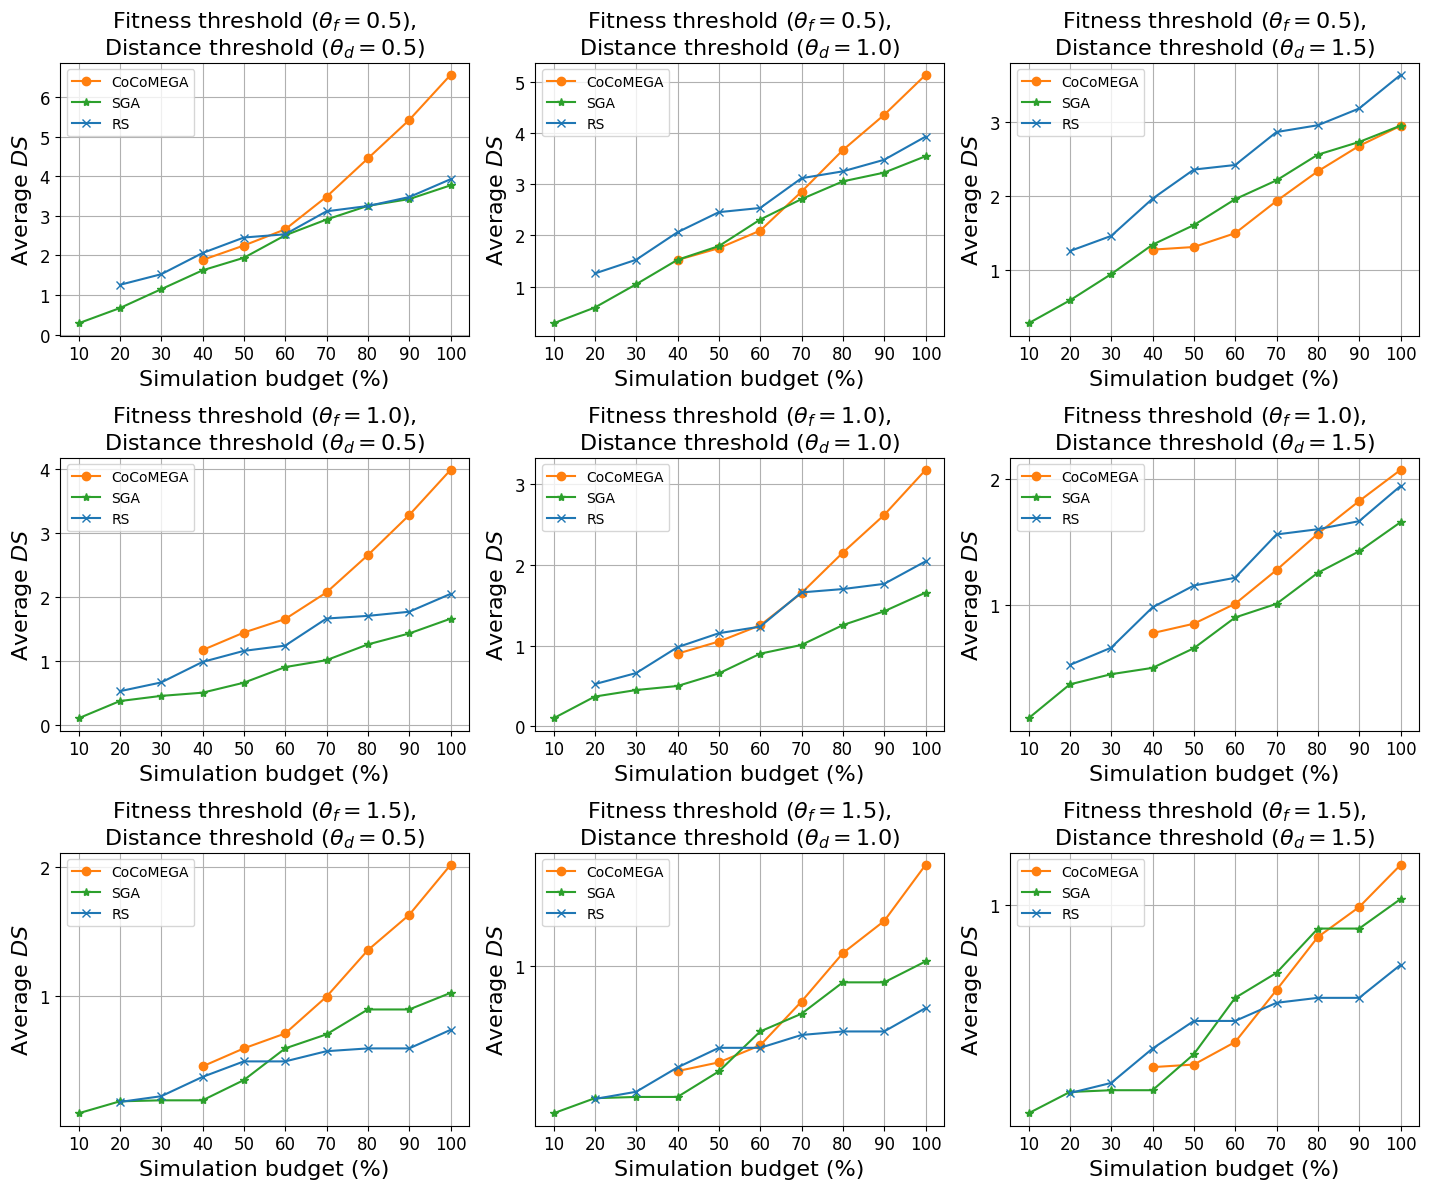

In [6]:
visualize_distinct_solution_over_simulations("out/checkpoints", set1_checkpoints,
                                             fitness_thresholds=[0.5, 1.0, 1.5],
                                             distance_thresholds=[0.5, 1.0, 1.5],
                                             max_sim_num=200, mrc=False, mr_set=mr_set1, show=True)

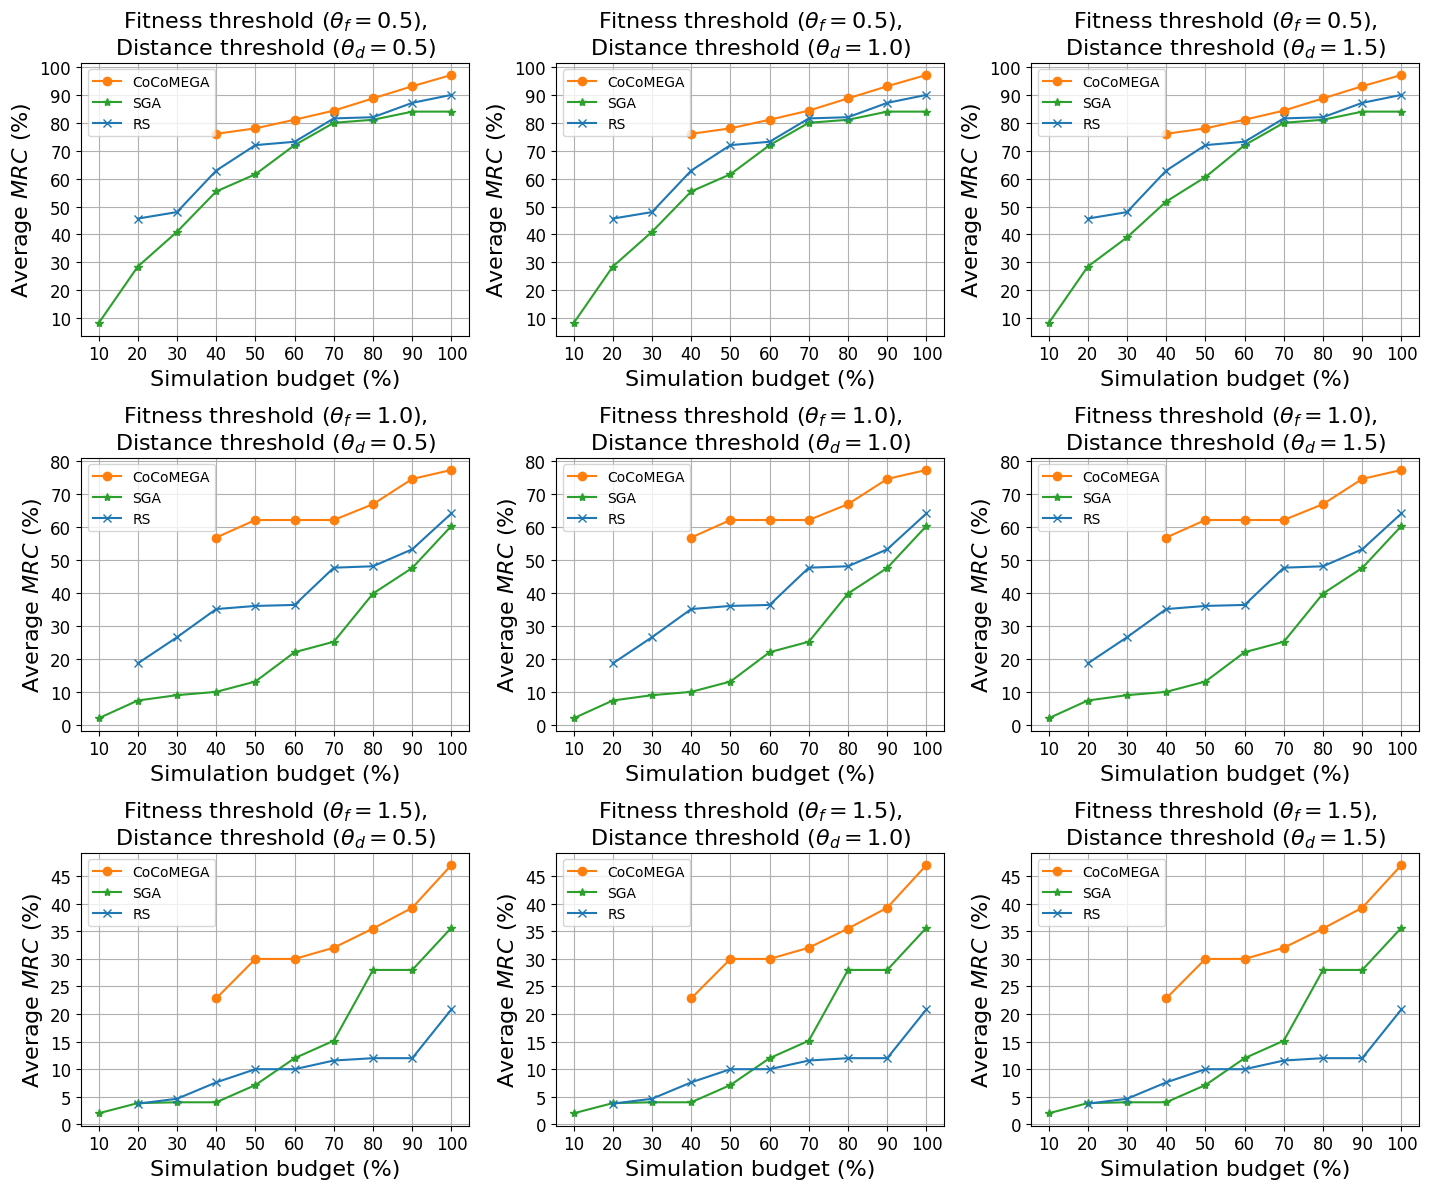

In [19]:
visualize_distinct_solution_over_simulations("out/checkpoints", set1_checkpoints,
                                             fitness_thresholds=[0.5, 1.0, 1.5],
                                             distance_thresholds=[0.5, 1.0, 1.5],
                                             max_sim_num=200, mrc=True, mr_set=mr_set1, show=True)

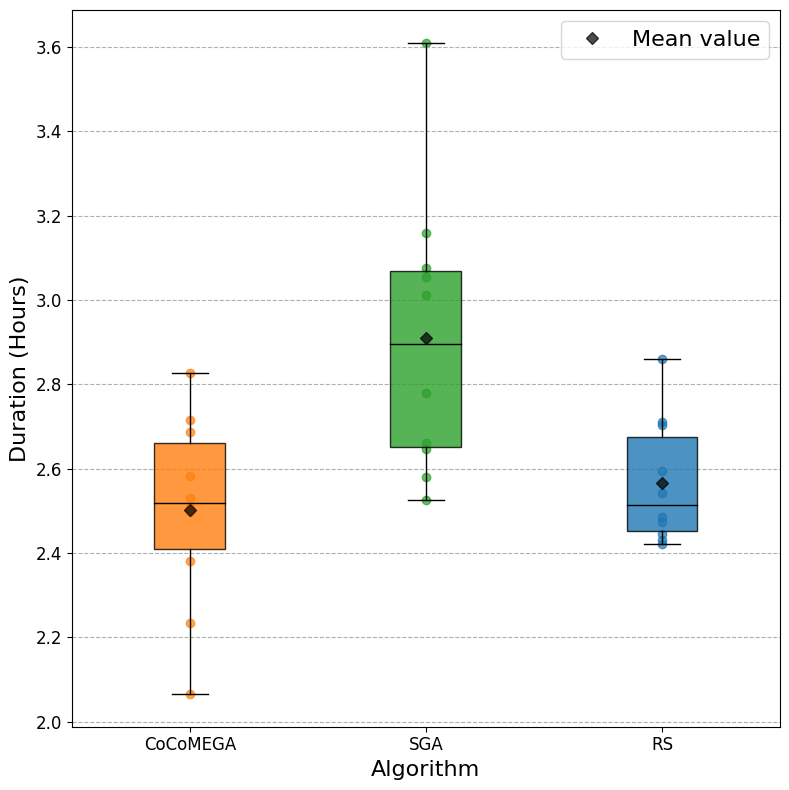

In [19]:
visualize_computational_efficiency("out/logs/started_logs.log", set1_solutions, set1_checkpoints, show=True)

## MR set 2

2025-04-01 17:06:25,688  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:27,321  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:28,060  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:28,828  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:30,571  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:31,390  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:32,072  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)
2025-04-01 17:06:34,421  WARNING  2338183 --- The new model value is identical to the original. (scenario_definition.py:534)


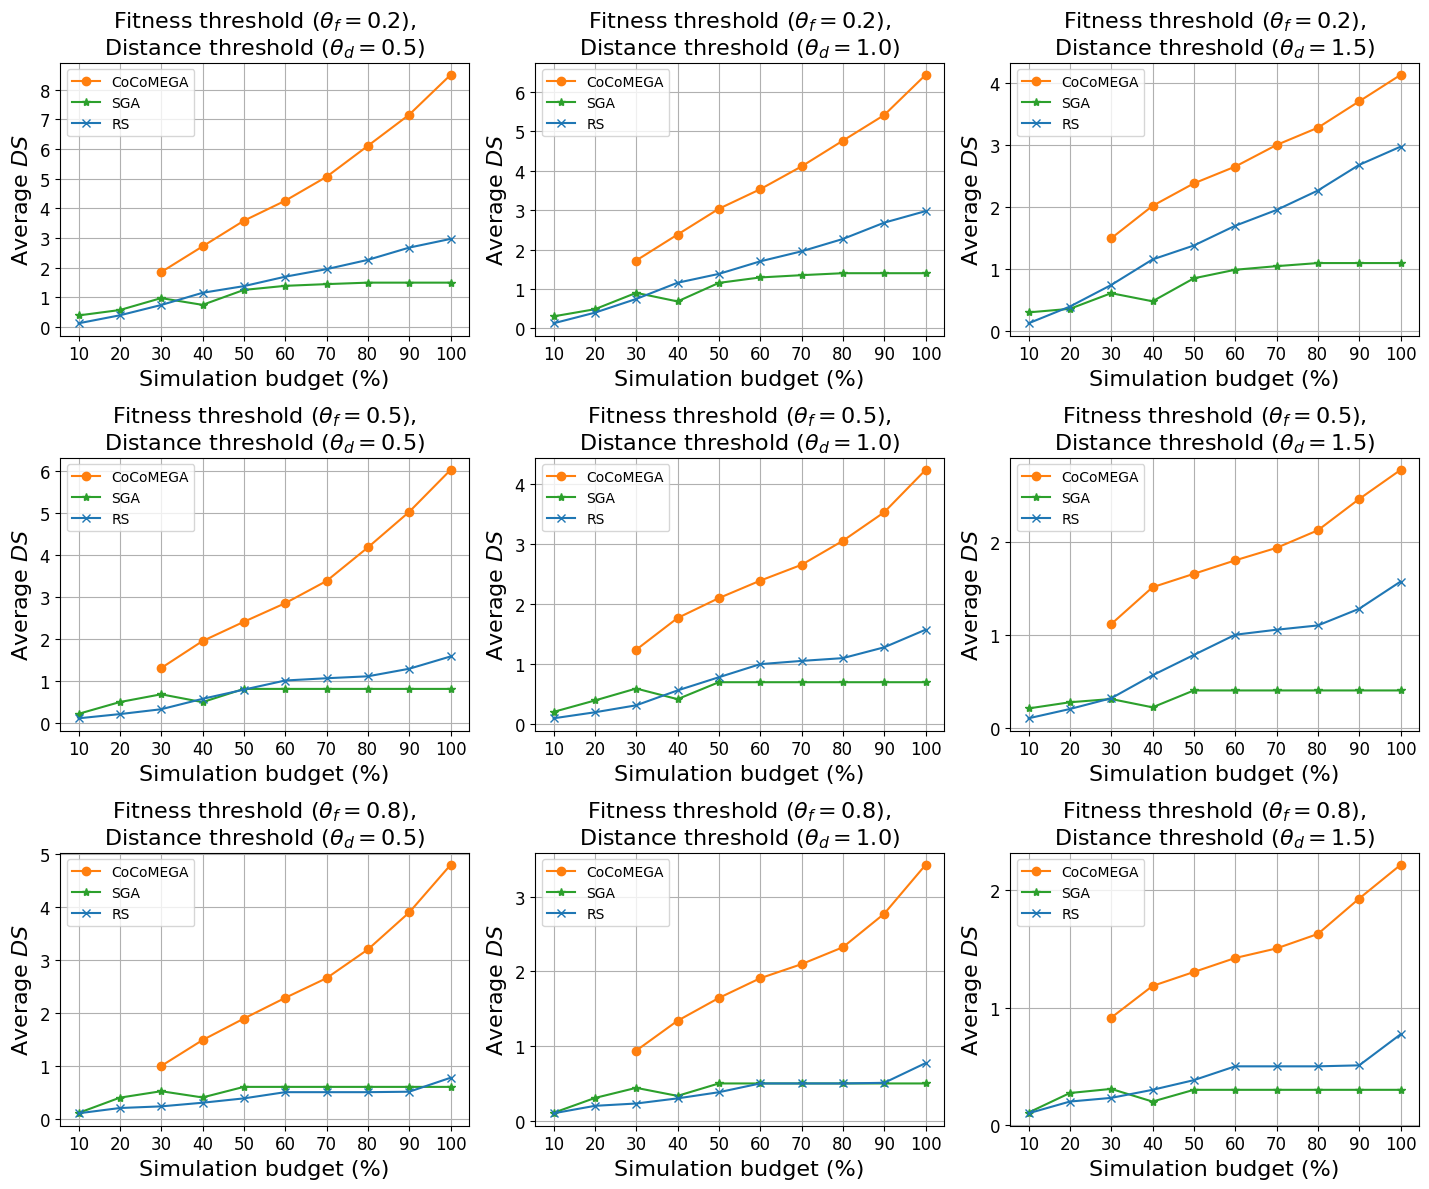

In [7]:
visualize_distinct_solution_over_simulations("out/checkpoints", set2_checkpoints,
                                             fitness_thresholds=[0.2, 0.5, 0.8],
                                             distance_thresholds=[0.5, 1.0, 1.5],
                                             max_sim_num=200, mrc=False, mr_set=mr_set3, show=True)

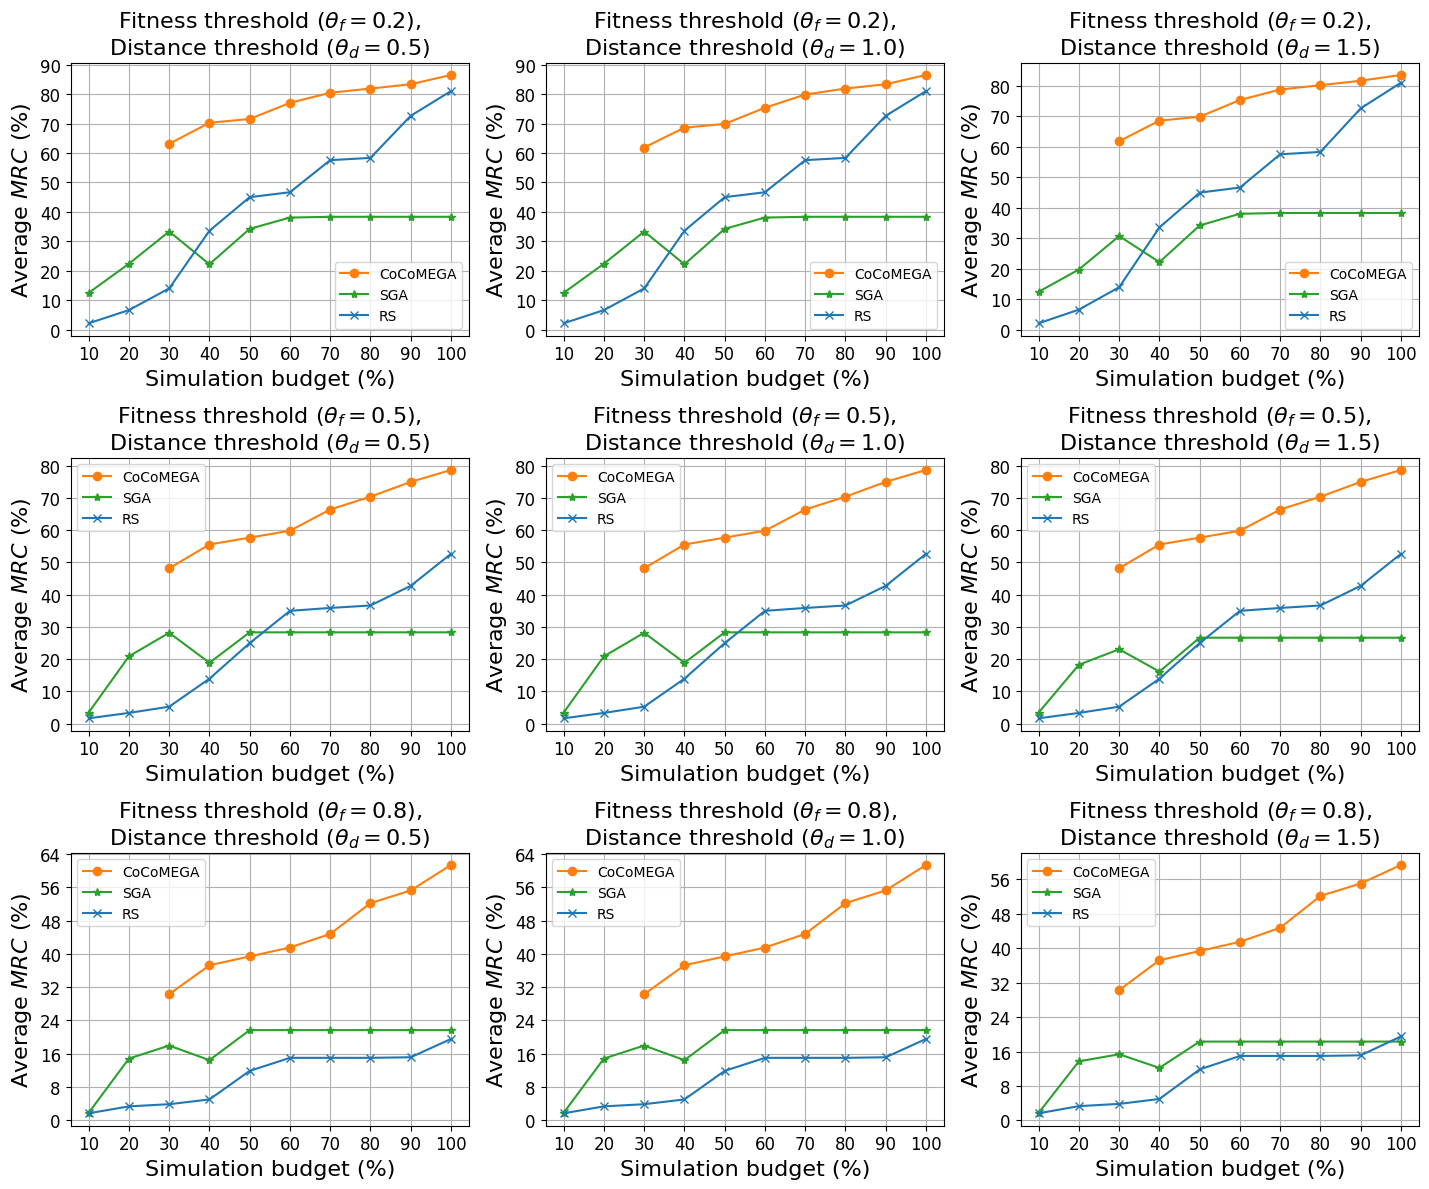

In [21]:
visualize_distinct_solution_over_simulations("out/checkpoints", set2_checkpoints,
                                             fitness_thresholds=[0.2, 0.5, 0.8],
                                             distance_thresholds=[0.5, 1.0, 1.5],
                                             max_sim_num=200, mrc=True, mr_set=mr_set3, show=True)

# Plots for RQ3

In [22]:
fitnesses, dists = quantile(set1_solutions)
print(np.quantile(fitnesses, [0.5, 0.7, 0.9]).round(1))
print(np.quantile(dists, [0.1, 0.3, 0.5]).round(1))

[0.3 0.8 1.5]
[1.1 1.5 1.7]


Average improvement of CoCoMEGA compared to CoCoMEGA-d: 91.08%


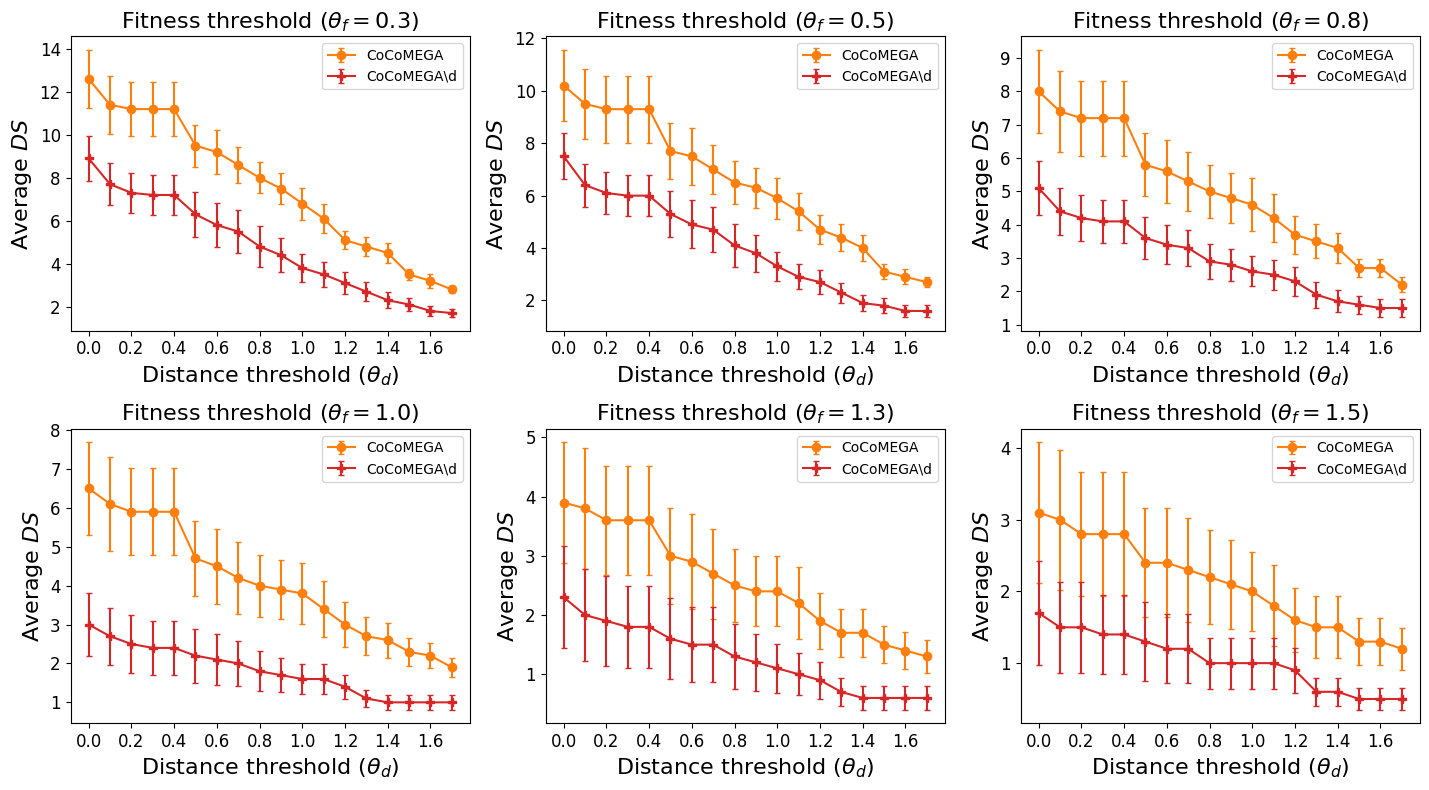

In [4]:
diversity_solution_stats = visualize_archived_distinct_solutions(
    {name: [f"out/solutions/solutions-ccea-{time}.pickle" for time in times]
     for name, times in diversity_solutions.items()},
    fitness_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
    distance_thresholds=np.arange(0, 1.71, 0.1).round(1),
    mr_set=mr_set1, box=False, show=True)

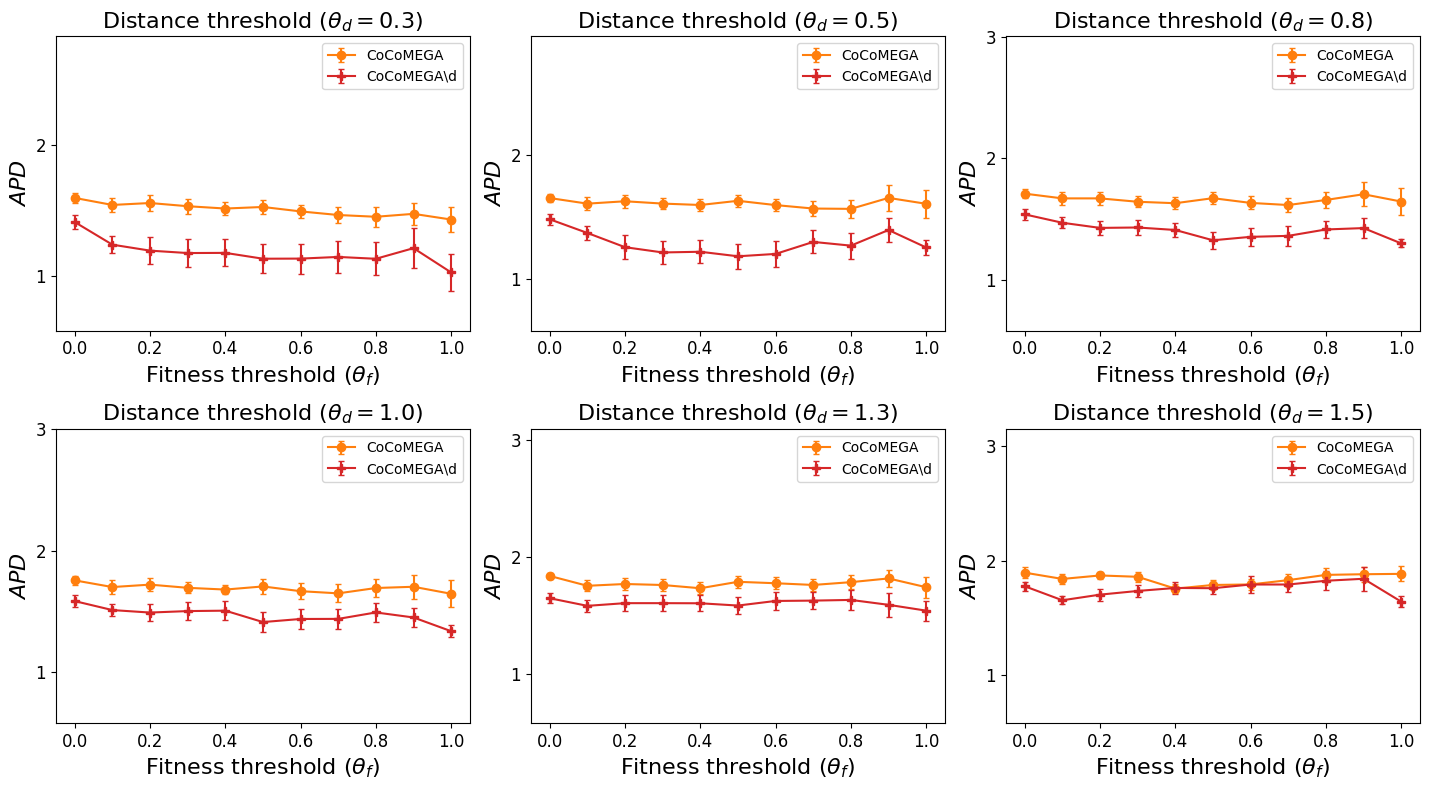

In [24]:
visualize_archived_solutions_by_gen("out/checkpoints", diversity_checkpoints, generation_num=7, metric_name="avg_pw",
                                    fitness_thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                    distance_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
                                    mr_set=mr_set1, box=False, show=True,
                                    legend_loc="upper right", padding={"top": 1.2, "bottom": 0.3})

# Tables for RQ3

In [25]:
print_table(diversity_solution_stats,
            fitness_thresholds=[0.3, 0.5, 0.8, 1.0, 1.3, 1.5],
            distance_thresholds=[0.0, 1.0, 1.7],
            mr_set=mr_set1)

\toprule
\multirow{2}{2em}{\(\boldsymbol{\theta_d}\)}&\multirow{2}{*}{\textbf{Method}}&\multicolumn{6}{c}{\textbf{Average \emph{\gls{mrc}}\(\boldsymbol{\pm CI_{0.95}}\) (Average \emph{\gls{cmr}}\(\boldsymbol{\pm CI_{0.95}}\))}}\\
\cmidrule{3-8}
&&\(\theta_f=0.3\)&\(\theta_f=0.5\)&\(\theta_f=0.8\)&\(\theta_f=1.0\)&\(\theta_f=1.3\)&\(\theta_f=1.5\)\\
\midrule
\multirow{6}{2em}{\(\theta_d=0.0\)}&\emph{\gls{ours}}&\(100.0\pm0.0\) (\(3.0\pm0.3\))&\(98.0\pm1.8\) (\(2.6\pm0.3\))&\(90.0\pm7.2\) (\(2.1\pm0.3\))&\(78.0\pm10.9\) (\(1.8\pm0.4\))&\(66.0\pm12.3\) (\(1.3\pm0.3\))&\(56.0\pm13.1\) (\(1.0\pm0.3\))\\
&\emph{\gls{ours}\textbackslash{}d}&\(86.0\pm7.6\) (\(2.9\pm0.4\))&\(86.0\pm7.6\) (\(2.5\pm0.4\))&\(82.0\pm9.1\) (\(2.2\pm0.3\))&\(56.0\pm12.0\) (\(1.4\pm0.4\))&\(34.0\pm11.7\) (\(1.1\pm0.4\))&\(34.0\pm11.7\) (\(0.9\pm0.3\))\\
\midrule
\multirow{6}{2em}{\(\theta_d=1.0\)}&\emph{\gls{ours}}&\(100.0\pm0.0\) (\(2.9\pm0.3\))&\(98.0\pm1.8\) (\(2.6\pm0.3\))&\(90.0\pm7.2\) (\(2.1\pm0.3\))&\(78.0\pm1

In [6]:
ours_mrc_0   = [100.0,  98.0,  90.0,  78.0,  66.0,  56.0]
sga_mrc_0    = [ 86.0,  86.0,  82.0,  56.0,  34.0,  34.0]

# theta_d = 1.0
ours_mrc_1   = [100.0,  98.0,  90.0,  78.0,  66.0,  56.0]
sga_mrc_1    = [ 84.0,  84.0,  80.0,  54.0,  32.0,  32.0]

# theta_d = 1.7
ours_mrc_17  = [ 98.0,  94.0,  86.0,  78.0,  64.0,  56.0]
sga_mrc_17   = [ 66.0,  70.0,  68.0,  50.0,  28.0,  28.0]

ours_cmr_0   = [3.0,  2.6, 2.1, 1.8, 1.3, 1.0]
sga_cmr_0    = [2.9,  2.5, 2.2, 1.4, 1.1, 0.9]

# theta_d = 1.0
ours_cmr_1   = [2.9,  2.6, 2.1, 1.8, 1.3, 1.0]
sga_cmr_1    = [2.3,  2.1, 1.9, 1.2, 0.9, 0.8]

# theta_d = 1.7
ours_cmr_17  = [2.0,  2.1, 1.6, 1.3, 1.1, 1.0]
sga_cmr_17   = [1.5,  1.4, 1.2, 0.9, 0.6, 0.5]

import numpy as np

# Put the MRC data into arrays
ours_mrc = np.array([ours_mrc_0, ours_mrc_1, ours_mrc_17]).reshape(-1)
sga_mrc  = np.array([sga_mrc_0,  sga_mrc_1,  sga_mrc_17 ]).reshape(-1)

# Compute relative improvements for MRC
improve_mrc_ours_sga = 100.0 * (ours_mrc - sga_mrc) / sga_mrc

avg_improve_mrc_sga = np.mean(improve_mrc_ours_sga)

# Similarly for CMR
ours_cmr = np.array([ours_cmr_0, ours_cmr_1, ours_cmr_17]).reshape(-1)
sga_cmr  = np.array([sga_cmr_0,  sga_cmr_1,  sga_cmr_17 ]).reshape(-1)

improve_cmr_ours_sga = 100.0 * (ours_cmr - sga_cmr) / sga_cmr

avg_improve_cmr_sga = np.mean(improve_cmr_ours_sga)

print("Avg MRC improvement over SGA: %.2f%%" % avg_improve_mrc_sga)
print("Avg CMR improvement over SGA: %.2f%%" % avg_improve_cmr_sga)

Avg MRC improvement over SGA: 50.32%
Avg CMR improvement over SGA: 32.50%
